In [2]:
import sys 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_score,recall_score,f1_score,log_loss
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier

In [87]:
def parse_vector(vec_str):
    # Splitta la stringa su ";" e converte ciascun valore in float
    floats = [float(num_str) for num_str in vec_str.split(";")]
    return floats

In [77]:
def plot_siren_balance(y):
    siren=(np.count_nonzero(y)/len(y))
    not_siren=1-siren
    y.value_counts().plot(kind='pie', labels=['Not siren '+ str(round(not_siren,4)*100)+'%','Siren '+ str(round(siren,4)*100)+'%'],ylabel=(''),colors=['blue','red'],title="Distribution of siren and not siren")
    plt.show()


In [108]:
def model_tuning(model_name:str,X_train,y_train,X_val,y_val):
    
    if model_name == 'logistic_regression':
        logistic_regression = LogisticRegression()
        params = {
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear', 'saga'],  
            'max_iter': [40, 45 , 50, 70, 80, 100, 150, 200, 250, 300, 350],
            'class_weight': [None, 'balanced']
        }
        n_iterations = 50
        model_random_search = RandomizedSearchCV(
            estimator=logistic_regression,
            param_distributions=params,
            n_iter=n_iterations,
            random_state=42,
            n_jobs=-1 
        )

    elif model_name == 'decision_tree':
        tree_decision_classifier = tree.DecisionTreeClassifier()
        params = {
            'criterion': ['gini', 'entropy', 'log_loss'],
            'max_depth': list(range(2, 21)),      
            'min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9],
            'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
            'max_features': [None, 'sqrt', 'log2'],
            'class_weight': [None, 'balanced'],
            'ccp_alpha': [0.0, 0.01, 0.05, 0.1]
        }
        n_iterations = 50
        model_random_search = RandomizedSearchCV(
            estimator=tree_decision_classifier,
            param_distributions=params,
            n_iter=n_iterations,
            random_state=42,
            n_jobs=-1 
        )

    elif model_name == 'random_forest':
        random_forest = RandomForestClassifier()
        params = {
            'n_estimators': [50, 100, 150, 200, 300, 400],
            'criterion': ['gini', 'entropy', 'log_loss'],
            'max_depth': list(range(5, 31)),
            'min_samples_split': [2, 3, 4, 5, 6],
            'min_samples_leaf': [1, 2, 3, 4, 5, 6],
            'max_features': ['sqrt', 'log2', None],
            'bootstrap': [True, False],
            'class_weight': [None, 'balanced'],
            'ccp_alpha': [0.0, 0.01, 0.05, 0.1] #pruning
        }
        n_iterations = 50
        model_random_search = RandomizedSearchCV(
            estimator=random_forest,
            param_distributions=params,
            n_iter=n_iterations,
            random_state=42,
            n_jobs=-1
        )

    elif model_name == 'gradient_boosting':  
        g_boost = GradientBoostingClassifier()
        params = {
            'loss': ['log_loss', 'exponential'],
            'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2, 0.3],
            'n_estimators': [10, 20, 30, 40, 50, 70, 100, 150, 200, 250, 300, 350, 400, 500],
            'subsample': [0.5, 0.7, 1.0],
            'min_samples_leaf': [1, 2, 3, 4, 5, 6],
            'max_depth': list(range(2, 11)),
            'max_features': [None, 'sqrt', 'log2']
        }
        n_iterations = 50
        model_random_search = RandomizedSearchCV(
            estimator=g_boost,
            param_distributions=params,
            n_iter=n_iterations,
            random_state=42,
            n_jobs=-1
        )

    else:
        sys.exit('ERROR INPUT MODEL NAME')
      
    model_random_search.fit(X_train,y_train)
    y_pred_random = model_random_search.predict(X_val)
    precision = precision_score(y_val, y_pred_random)
    f1 = f1_score(y_val, y_pred_random)
    recall=recall_score(y_val,y_pred_random)
    print("Best results for ",model_name,"\n","precision: ",precision," recall: ",recall," f1: ",f1)
    print(model_random_search.best_params_)
    with open(model_name+'_random_search.txt', 'w') as f:
        f.write(str(model_random_search.best_params_))
    f.close()

In [79]:
df= pd.read_csv("all_audio_wav2vec_dataset_complete.csv")
#print(df["class"].unique())
df['class'] = df['class'].apply(lambda x: 1 if ((x == 'ambulance') or (x == 'firetruck') or (x == 'police') or (x == 'siren') ) else 0) #sostituisco 1 a tutti i tipi di sirene, 0 al resto

['dog' 'chirping_birds' 'vacuum_cleaner' 'thunderstorm' 'door_wood_knock'
 'can_opening' 'crow' 'clapping' 'fireworks' 'chainsaw' 'airplane'
 'mouse_click' 'pouring_water' 'train' 'sheep' 'water_drops'
 'church_bells' 'clock_alarm' 'keyboard_typing' 'wind' 'footsteps' 'frog'
 'cow' 'brushing_teeth' 'car_horn' 'crackling_fire' 'helicopter'
 'drinking_sipping' 'rain' 'insects' 'laughing' 'hen' 'engine' 'breathing'
 'crying_baby' 'hand_saw' 'coughing' 'glass_breaking' 'snoring'
 'toilet_flush' 'pig' 'washing_machine' 'clock_tick' 'sneezing' 'rooster'
 'sea_waves' 'siren' 'cat' 'door_wood_creaks' 'crickets' 'dog_bark'
 'children_playing' 'air_conditioner' 'street_music' 'gun_shot'
 'engine_idling' 'jackhammer' 'drilling' 'traffic' 'ambulance' 'firetruck'
 'police']


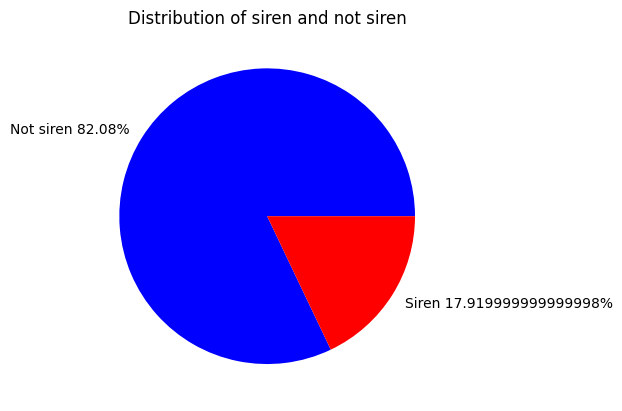

In [80]:
#plot_siren_balance(df["class"])

In [92]:
df3=df[df["snr"].isin([3])]
X_series = df3["vector"].apply(parse_vector)
X = np.array(X_series.tolist()) #embeddings audio
y=df3["class"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.30, stratify=y) #stratify mantiene la proporzione rispetto IMPORTANTE
X_train, X_validation, y_train, y_validation = train_test_split(X_train,y_train,test_size=0.30, stratify = y_train)

print("Results for 3db")
model_tuning('logistic_regression',X_train,y_train,X_validation,y_validation)
model_tuning('decision_tree',X_train,y_train,X_validation,y_validation)
model_tuning('random_forest',X_train,y_train,X_validation,y_validation)
model_tuning('grandient_boosting',X_train,y_train,X_validation,y_validation)

In [ ]:
df10=df[df["snr"].isin([10])]
X_series = df10["vector"].apply(parse_vector)
X = np.array(X_series.tolist()) #embeddings audio
y=df10["class"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.30, stratify=y) #stratify mantiene la proporzione rispetto IMPORTANTE
X_train, X_validation, y_train, y_validation = train_test_split(X_train,y_train,test_size=0.30, stratify = y_train)

print("Results for 10db")
model_tuning('logistic_regression',X_train,y_train,X_validation,y_validation)
model_tuning('decision_tree',X_train,y_train,X_validation,y_validation)
model_tuning('random_forest',X_train,y_train,X_validation,y_validation)
model_tuning('grandient_boosting',X_train,y_train,X_validation,y_validation)

In [ ]:
df20=df[df["snr"].isin([20])]
X_series = df20["vector"].apply(parse_vector)
X = np.array(X_series.tolist()) #embeddings audio
y=df20["class"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.30, stratify=y) #stratify mantiene la proporzione rispetto IMPORTANTE
X_train, X_validation, y_train, y_validation = train_test_split(X_train,y_train,test_size=0.30, stratify = y_train)

print("Results for 20db")
model_tuning('logistic_regression',X_train,y_train,X_validation,y_validation)
model_tuning('decision_tree',X_train,y_train,X_validation,y_validation)
model_tuning('random_forest',X_train,y_train,X_validation,y_validation)
model_tuning('grandient_boosting',X_train,y_train,X_validation,y_validation)

In [ ]:
X_series = df["vector"].apply(parse_vector)
X = np.array(X_series.tolist()) #embeddings audio
y=df["class"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.30, stratify=y) #stratify mantiene la proporzione rispetto IMPORTANTE
X_train, X_validation, y_train, y_validation = train_test_split(X_train,y_train,test_size=0.30, stratify = y_train)

print("Results for 0db + 3 db + 10db + 20db")
model_tuning('logistic_regression',X_train,y_train,X_validation,y_validation)
model_tuning('decision_tree',X_train,y_train,X_validation,y_validation)
model_tuning('random_forest',X_train,y_train,X_validation,y_validation)
model_tuning('grandient_boosting',X_train,y_train,X_validation,y_validation)